In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import warnings

from pathlib import Path

warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output


In [17]:
# Load data
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

df['Survived'] = df['Outcome of patient'].astype(str).str.contains("Discharged Alive", na=False).astype(int)

Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


In [18]:
# After loading df, define Outcome_Strict as in your snippet
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']
available_cols = [col for col in outcome_cols if col in df.columns]
df['Outcome_String'] = df[available_cols].astype(str).agg(' '.join, axis=1)
survival_regex = r'Discharged Alive|Remains In Hospital At 30Th Day'
is_survivor = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True)
is_good_neuro = df['Patient neurological status - Overall'].isin([1.0, 2.0])
df['Outcome_Strict'] = (is_survivor & is_good_neuro).astype(int)

In [19]:

# Filter valid times
data = df[df['Time_to_Defib'].notna() & (df['Time_to_Defib'] > 0)].copy()
t = data['Time_to_Defib'].values
y = data['Outcome_Strict'].values

# Restrict tau to plausible range where both sides have data
t_min = t.min()
t_max = t.max()
candidates = np.arange(t_min + 0.5, t_max - 0.5, 0.5)   # avoid extremes

best_tau = None
best_ll = -np.inf

for tau in candidates:
    X = np.column_stack([np.ones_like(t), t, np.maximum(0, t - tau)])
    # Use BFGS with more iterations to avoid singular Hessian warnings
    try:
        model = sm.Logit(y, X).fit(method='bfgs', maxiter=500, disp=0)
        if model.llf > best_ll:
            best_ll = model.llf
            best_tau = tau
    except:
        continue

print(f"Estimated τ₁ = {best_tau:.1f} minutes")

Estimated τ₁ = 13.7 minutes


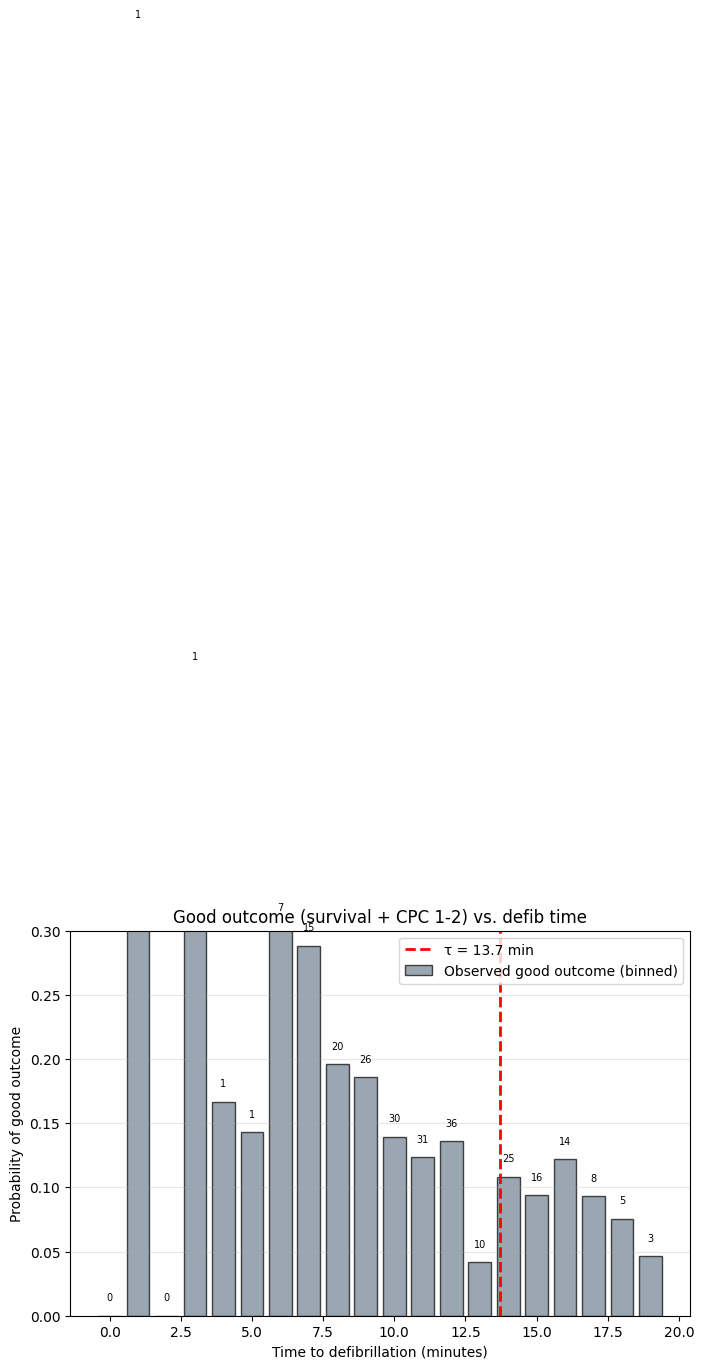

In [20]:
# Use the same filtered data and best_tau from earlier
data = df[df['Time_to_Defib'].notna() & (df['Time_to_Defib'] > 0)].copy()
t = data['Time_to_Defib'].values
y = data['Survived'].values

# Bin by floor of minutes
data['Time_Bin'] = np.floor(data['Time_to_Defib']).astype(int)
binned = data.groupby('Time_Bin')['Outcome_Strict'].agg(['count', 'sum']).reset_index()
binned = binned[binned['count'] > 0]

plt.figure(figsize=(8,5))
bars = plt.bar(binned['Time_Bin'], binned['sum'] / binned['count'],
               width=0.8, color='slategray', alpha=0.7, edgecolor='black',
               label='Observed good outcome (binned)')

# Add survivor counts
for bar, surv in zip(bars, binned['sum']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{int(surv)}', ha='center', va='bottom', fontsize=7)

plt.axvline(x=best_tau, color='red', linestyle='--', linewidth=2,
            label=f'τ = {best_tau:.1f} min')

plt.xlabel('Time to defibrillation (minutes)')
plt.ylabel('Probability of good outcome')
plt.title('Good outcome (survival + CPC 1‑2) vs. defib time')
plt.legend(loc='upper right')
plt.ylim(0, 0.3)   # adjust if needed
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()